# Libraries

In [1]:
import pandas as pd
import sklearn.utils.stats as stats
import os
import numpy as np
from scipy.stats.contingency import chi2_contingency
from scipy.stats import chi2

# Preparing Data

### Downloading Data

In [2]:
os.environ['KAGGLEHUB_CACHE'] = os.curdir

if not os.path.isdir('datasets'):
    import kagglehub
    path = kagglehub.dataset_download("faviovaz/marketing-ab-testing")
else:
    path = os.path.join('datasets','faviovaz','marketing-ab-testing','versions','1')
    
path = os.path.join(path, 'marketing_AB.csv')
print("Path to dataset files:", path)

Path to dataset files: datasets\faviovaz\marketing-ab-testing\versions\1\marketing_AB.csv


### Inspecting Data

In [3]:
df = pd.read_csv(path).drop('Unnamed: 0', axis = 1)
df

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14
...,...,...,...,...,...,...
588096,1278437,ad,False,1,Tuesday,23
588097,1327975,ad,False,1,Tuesday,23
588098,1038442,ad,False,3,Tuesday,23
588099,1496395,ad,False,1,Tuesday,23


In [4]:
df['test group'].value_counts()

test group
ad     564577
psa     23524
Name: count, dtype: int64

# Hypothesis Testing

- Null Hypothesis = There is no significant change
- Alternative Hypothesis = There is a significant change

In [5]:
grouped_df = df.groupby('test group').agg({'converted':'sum', 'user id':'count','total ads':'sum', 'most ads hour':'mean'})
grouped_df

,converted,user id,total ads,most ads hour
test group,,,,
ad,14423,564577,14014701,14.475900
psa,420,23524,582481,14.304923


In [6]:
grouped_df['conversion rate'] = grouped_df['converted']/grouped_df['user id']
grouped_df

,converted,user id,total ads,most ads hour,conversion rate
test group,,,,,
ad,14423,564577,14014701,14.475900,0.025547
psa,420,23524,582481,14.304923,0.017854


In [7]:
ad_total, psa_total = grouped_df['user id']['ad'], grouped_df['user id']['psa']
ad_conv, psa_conv = grouped_df['converted']['ad'], grouped_df['converted']['psa']

In [8]:
table = np.array([
    [ad_conv, ad_total - ad_conv],
    [psa_conv, psa_total - psa_conv]
])

contingency_table = pd.DataFrame(table, columns = ['converted','not converted'], index = ['ad','psa'])

contingency_table

,converted,not converted
ad,14423,550154
psa,420,23104


In [9]:
chi2, p, dof, expected = chi2_contingency(contingency_table)
p

np.float64(1.9989623063390075e-13)

In [10]:
alpha = 0.05

print('There is a significant difference' if alpha > p else 'There is not enough evidence')

There is a significant difference


<Axes: >

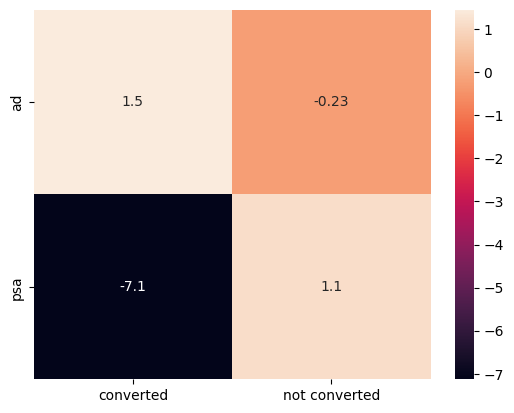

In [11]:
residuals = (contingency_table - expected) / np.sqrt(expected)

import seaborn as sns

sns.heatmap(residuals, annot = True)